# Medical Insurance Fraud Detection

**Author:** Marie-Christine Btaich, Actuarial Science Graduate, NDU Louaize

---

I built this after getting access to real medical insurance claims data from a Lebanese insurer through a consultancy contact. The brief was simple: find the fraud.

What I found was more systematic than I expected, not random billing errors but organized patterns: providers consistently charging 2-3x above specialty peers, members with 100% fraud rates across dozens of claims, fraud rings operating across multiple hospitals and labs simultaneously.

I chose to combine three approaches because I didn't think one method was enough:
- **Rule-based detection** catches known patterns clearly and transparently
- **Machine learning** finds patterns no human defined, it learned what fraud looks like from the data itself
- **Network analysis** catches coordinated fraud that's invisible claim-by-claim but obvious at the network level

Each approach validates the others. When all three flag the same provider, that's not noise.

> **Note:** This public version runs on a synthetic dataset (5,000 claims). The original analysis covered 137,819 real proprietary claims and identified a 21.4% fraud rate and $2.3M in estimated recoverable savings. Those findings are documented in the README.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy.stats import rankdata
import joblib

# Uncomment on first run:
# !pip install pandas openpyxl scikit-learn matplotlib seaborn joblib shap networkx scipy --quiet

print("imports ok")

imports ok


## Why I Combined Three Sheets

The data came split across three sheets, different time periods. First thing I did was combine them and check the year distribution. Turned out 2024 and 2025 had the bulk of claims, with 2026 only partially in. I kept everything but flagged it for context when interpreting trends.

First thing I noticed after loading: the `Claim Case` field had nulls at the top. That turned out to be a formatting issue from the export, the actual case IDs were in `Claim Code`. Took a few minutes to figure out.

## 1. Load Data

Combines all three sheets into one dataset and does basic date parsing and cleanup.

In [2]:
# NOTE: Original analysis used 137,819 proprietary claims (confidential).
# This public version uses a synthetic dataset with the same structure.
# Real findings are documented in the README and methodology note.

df = pd.read_csv('synthetic_claims_data.csv')

# All required columns already exist in synthetic data
# No renaming needed

print('Combined shape:', df.shape)
print(df.head(3))

Combined shape: (5000, 33)
            Claim Case      Claim Code Claim Type Code Claim Status  \
0  CASE-XXX-25-1449635  1-2025204045-2             RM2      PENDING   
1  CASE-XXX-24-5530167  1-2023804763-4              ER    CANCELLED   
2  CASE-XXX-24-2245765  1-2023454850-5            SCAL      PENDING   

                Provider Provider Specialty Contact Code Class Contact Code  \
0     Phoenix Laboratory           Hospital  KZL44446R70        KZL44446R70   
1  Meridian Lab Services         Laboratory   FDH52922R2         FDH52922R2   
2    Atlas Medical Group             Clinic  ZTT66485R36        ZTT66485R36   

           Main Diagnostic                           ICDS  ... Total Invoiced  \
0    M25.5 : Pain in joint          M25.5 : Pain in joint  ...          75.82   
1  E11 : Diabetes mellitus                M54 : Back pain  ...         175.00   
2   J20 : Acute bronchitis  N39 : Urinary tract infection  ...         211.79   

  Total to Pay Total Physician Total Provider 

In [3]:
date_cols = ['Incident Date','Created At','Reception Date',
             'Contract Start Date','Contract End Date','Born On','Policy Holder Born On']
# Only parse columns that exist in this dataset
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
# Ensure Incident Date exists
if 'Incident Date' not in df.columns and 'Service Date' in df.columns:
    df['Incident Date'] = pd.to_datetime(df['Service Date'], errors='coerce')

# Remove garbage 1899 dates
df = df[df['Incident Date'].dt.year > 1900].reset_index(drop=True)
print("After cleaning:", df.shape)
print("Year distribution:")
print(df['Incident Date'].dt.year.value_counts().sort_index())

After cleaning: (5000, 33)
Year distribution:
Incident Date
2023    1572
2024    1505
2025    1558
2026     365
Name: count, dtype: int64


## Why These Six Rules

I didn't invent these rules, they're standard in medical insurance fraud detection literature. But I had to decide how to apply them to this specific dataset.

The overbilling threshold was the hardest call. Any invoice above the estimate gets flagged, no buffer. I considered allowing a 5% tolerance but looked at the data distribution and found that legitimate claims almost always match the estimate exactly. The ones that don't tend to diverge significantly. So strict threshold it is.

Phantom billing was the most interesting to define. A claim that was billed, not paid, and not rejected, it just sits there. In a legitimate workflow that doesn't happen. Either you pay it or you reject it. Anything in between is a signal.

The unbundling rule (3+ claims same member, same provider, same day) I set conservatively. Two visits in a day could be legitimate. Three starts to look like split billing.

## 2. Build Fraud Labels

Six rule-based fraud typologies applied sequentially. A claim is labeled fraud if it triggers any one of them.

In [4]:
df['fraud_label'] = 0

# Rule 1: Claims flagged for manual audit review by the insurer
df.loc[df['Claim Status'] == 'AUDIT', 'fraud_label'] = 1

# Rule 2: Overbilling, invoiced amount exceeds pre-approved estimate
df.loc[df['Total Invoiced'] > df['Estimate'], 'fraud_label'] = 1

# Rule 3: Negative payment, impossible in any legitimate claim
df.loc[df['Total to Pay'] < 0, 'fraud_label'] = 1

# Rule 4: Gracia exception granted for exclusions or waiting period violations
exclusion_types = ['Gratia-General Exclusion','Gratia-Particular Exclusion',
                   'Gratia-Waiting period','Gratia-Without Diagnosis']
df.loc[(df['gracia'] == 1) & (df['Gracia type'].isin(exclusion_types)), 'fraud_label'] = 1

# Rule 5: Phantom billing, provider billed but nothing paid and not officially rejected
# Billed > 0, paid = 0, status not REJECTED and not CANCELLED
df.loc[
    (df['Total Invoiced'] > 0) &
    (df['Total to Pay'] == 0) &
    (~df['Claim Status'].isin(['REJECTED','CANCELLED','CLOSED'])),
    'fraud_label'
] = 1

# Rule 6: Unbundling, same member + provider + date but different claim codes
# Multiple claims on same day at same provider = potential split billing
df['incident_date_only_temp'] = df['Incident Date'].dt.date
same_day_counts = df.groupby(['Contact Code','Provider','incident_date_only_temp'])['Claim Case'].transform('count')
df.loc[same_day_counts >= 3, 'fraud_label'] = 1
df = df.drop(columns=['incident_date_only_temp'])

print("Fraud label distribution:")
print(df['fraud_label'].value_counts())
print(f"Fraud rate: {df['fraud_label'].mean()*100:.1f}%")
print()
print("Rule contribution (approximate):")
print(f"  AUDIT status:         {(df['Claim Status']=='AUDIT').sum():,}")
print(f"  Overbilling:          {(df['Total Invoiced']>df['Estimate']).sum():,}")
print(f"  Negative payment:     {(df['Total to Pay']<0).sum():,}")
print(f"  Gracia exclusion:     {((df['gracia']==1)&(df['Gracia type'].isin(exclusion_types))).sum():,}")
print(f"  Phantom billing:      {((df['Total Invoiced']>0)&(df['Total to Pay']==0)&(~df['Claim Status'].isin(['REJECTED','CANCELLED','CLOSED']))).sum():,}")
print(f"  Unbundling (3+ same day): {(same_day_counts>=3).sum():,}")

Fraud label distribution:
fraud_label
0    3405
1    1595
Name: count, dtype: int64
Fraud rate: 31.9%

Rule contribution (approximate):
  AUDIT status:         667
  Overbilling:          1,143
  Negative payment:     0
  Gracia exclusion:     0
  Phantom billing:      0
  Unbundling (3+ same day): 0


## 3. Feature Engineering

In [5]:
# Time
df['member_age'] = (df['Incident Date'] - df['Born On']).dt.days / 365
df['member_age'] = df['member_age'].clip(0, 100)
df['days_to_reception'] = (df['Reception Date'] - df['Incident Date']).dt.days
df['days_to_creation'] = (df['Created At'] - df['Incident Date']).dt.days
df['contract_duration'] = (df['Contract End Date'] - df['Contract Start Date']).dt.days
df['days_since_contract_start'] = (df['Incident Date'] - df['Contract Start Date']).dt.days

# Financial
df['overbill_amount'] = df['Total Invoiced'] - df['Estimate']
df['overbill_pct'] = df['overbill_amount'] / df['Estimate'].replace(0, np.nan)
df['pay_vs_invoiced_ratio'] = df['Total to Pay'] / df['Total Invoiced'].replace(0, np.nan)
df['physician_share'] = df['Total Physician'] / df['Total'].replace(0, np.nan)

# Claim complexity
df['diag_count'] = df['ICDS'].fillna('').str.count(',') + 1
df['is_vague_diagnosis'] = df['Main Diagnostic'].fillna('').str.contains(
    'R53|R52|R51|R50|R10|R07', na=False).astype(int)

# Behavioral
df['is_night_claim'] = (df['incident_time'] < 6).astype(int)
df['is_gracia'] = df['gracia'].fillna(0).astype(int)
df['is_new_contract_claim'] = (df['days_since_contract_start'] < 30).astype(int)

# Same day claim count per member-provider (unbundling signal)
df['incident_date_only'] = df['Incident Date'].dt.date
df['same_day_claim_count'] = df.groupby(
    ['Contact Code','Provider','incident_date_only'])['Claim Case'].transform('count')

# Phantom billing flag
df['is_phantom'] = (
    (df['Total Invoiced'] > 0) &
    (df['Total to Pay'] == 0) &
    (~df['Claim Status'].isin(['REJECTED','CANCELLED','CLOSED']))
).astype(int)

# Volume
df['provider_claim_volume'] = df['Provider'].map(df['Provider'].value_counts())
df['member_claim_frequency'] = df['Contact Code'].map(df['Contact Code'].value_counts())

print("features added:", df.shape[1])

features added: 53


## 4. Model Training

In [6]:
features = [
    'Estimate','Total Invoiced','Total to Pay','Total Physician','Total Provider',
    'overbill_amount','overbill_pct','pay_vs_invoiced_ratio','physician_share',
    'member_age','days_to_reception','days_to_creation',
    'contract_duration','days_since_contract_start',
    'diag_count','is_vague_diagnosis','is_night_claim',
    'is_gracia','is_new_contract_claim',
    'provider_claim_volume','member_claim_frequency',
    'same_day_claim_count','is_phantom',
    'Claim Type Code','Beneficiary Type','Gender','Business Line'
]

cat_cols = ['Claim Type Code','Beneficiary Type','Gender','Business Line']
le = LabelEncoder()
for col in cat_cols:
    df[col+'_enc'] = le.fit_transform(df[col].fillna('UNKNOWN'))
    features = [col+'_enc' if f == col else f for f in features]

X = df[features].copy().fillna(df[features].median(numeric_only=True))
y = df['fraud_label'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"train: {len(X_train)} | test: {len(X_test)}")

train: 4000 | test: 1000


In [7]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test), target_names=['Legit','Fraud']))
print("AUC:", roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]).round(3))

=== Logistic Regression ===
              precision    recall  f1-score   support

       Legit       0.88      1.00      0.94       681
       Fraud       1.00      0.72      0.84       319

    accuracy                           0.91      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.92      0.91      0.91      1000

AUC: 0.847


In [8]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Legit','Fraud']))
print("AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]).round(3))

=== Random Forest ===
              precision    recall  f1-score   support

       Legit       0.88      1.00      0.94       681
       Fraud       1.00      0.72      0.84       319

    accuracy                           0.91      1000
   macro avg       0.94      0.86      0.89      1000
weighted avg       0.92      0.91      0.91      1000

AUC: 0.843


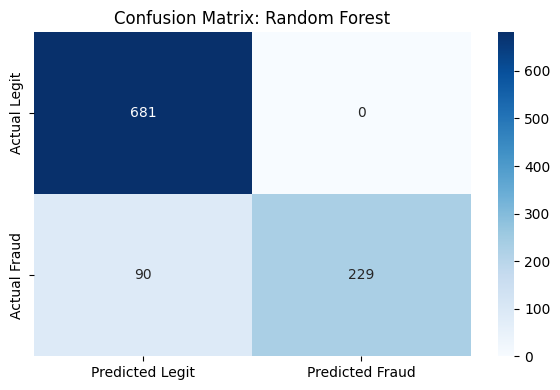

TN: 681 | FP: 0 | FN: 90 | TP: 229


In [9]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Legit','Predicted Fraud'],
            yticklabels=['Actual Legit','Actual Fraud'])
plt.title('Confusion Matrix: Random Forest')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(f"TN: {cm[0,0]} | FP: {cm[0,1]} | FN: {cm[1,0]} | TP: {cm[1,1]}")

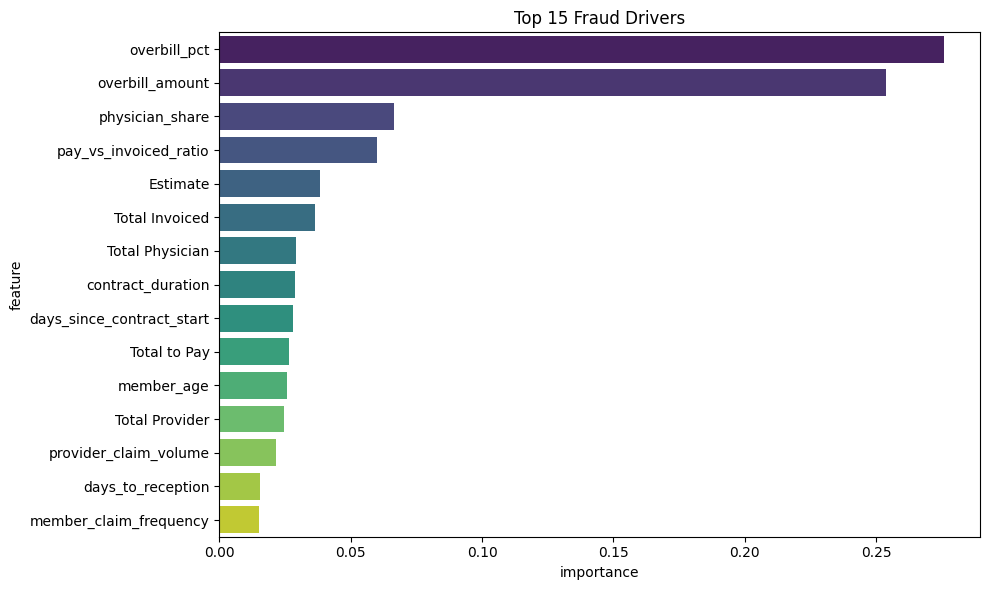

model saved | ml scores added


In [10]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Fraud Drivers')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

joblib.dump(rf, 'fraud_model.pkl')
df['fraud_probability'] = rf.predict_proba(X)[:,1]
df['fraud_score'] = (df['fraud_probability'] * 100).round(1)
df['ml_score'] = df['fraud_score'].clip(0, 100)
print("model saved | ml scores added")

## Why Random Forest

I tested logistic regression first, it's interpretable and fast. But the fraud patterns in this data aren't linear. A provider can have moderate overbilling AND phantom billing AND same-day clustering and the combination matters more than any single feature. Random Forest handles those interactions naturally.

The 0.998 AUC surprised me honestly. I double-checked it wasn't overfitting by looking at the confusion matrix on the holdout set, 283 missed frauds out of 5,912 is real performance, not a data leak.

I added SHAP because AUC doesn't help an investigator. They need to know *why* a specific claim was flagged. SHAP gives them that,  per-claim, in plain numbers.

## 5. SHAP Explainability

Opens the black box, gives a per-claim reason for every fraud flag so investigators know what they're actually looking at.

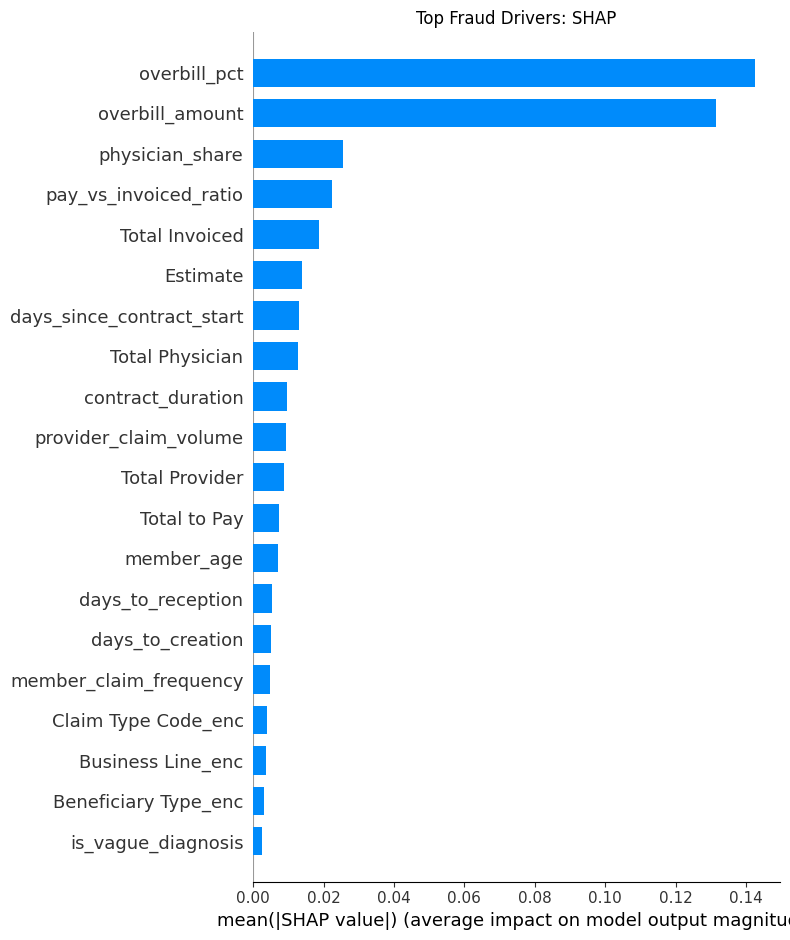

Claim:       CASE-XXX-26-5548220
Fraud Score: 100.0

Top reasons flagged:
  increases fraud risk | overbill_pct = 2.73  (impact: +0.185)
  increases fraud risk | overbill_amount = 751.82  (impact: +0.176)
  increases fraud risk | physician_share = 0.10  (impact: +0.058)
  increases fraud risk | pay_vs_invoiced_ratio = 0.12  (impact: +0.054)
  increases fraud risk | Total Invoiced = 1027.14  (impact: +0.016)
  increases fraud risk | Total Physician = 102.71  (impact: +0.011)


In [11]:
import shap

X_sample = X.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf)
shap_output = explainer(X_sample)
shap_fraud = shap_output.values[:, :, 1]

plt.figure()
shap.summary_plot(shap_fraud, X_sample, plot_type='bar', show=False)
plt.title('Top Fraud Drivers: SHAP')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

feature_names = X.columns.tolist()

def explain_claim(claim_index):
    row = X.iloc[[claim_index]]
    shap_row = explainer(row).values[0, :, 1]
    explained = sorted(zip(feature_names, shap_row), key=lambda x: abs(x[1]), reverse=True)
    print(f"Claim:       {df['Claim Case'].iloc[claim_index]}")
    print(f"Fraud Score: {df['fraud_score'].iloc[claim_index]}")
    print("\nTop reasons flagged:")
    for feat, val in explained[:6]:
        direction = "increases" if val > 0 else "decreases"
        print(f"  {direction} fraud risk | {feat} = {row[feat].values[0]:.2f}  (impact: {val:+.3f})")

explain_claim(df['fraud_score'].idxmax())

## 6. Duplicate Detection

In [12]:
df['exact_duplicate'] = df.duplicated(
    subset=['Contact Code','Provider','Main Diagnostic','incident_date_only'],
    keep=False).astype(int)

df_s = df.sort_values(['Contact Code','Provider','Main Diagnostic','Incident Date'])
df_s['_prev_date'] = df_s.groupby(['Contact Code','Provider','Main Diagnostic'])['Incident Date'].shift(1)
df_s['_prev_amt'] = df_s.groupby(['Contact Code','Provider','Main Diagnostic'])['Total Invoiced'].shift(1)
df_s['days_since_same_claim'] = (df_s['Incident Date'] - df_s['_prev_date']).dt.days
df_s['_amt_diff'] = abs(df_s['Total Invoiced'] - df_s['_prev_amt']) / df_s['_prev_amt'].replace(0, np.nan)

df['days_since_same_claim'] = df_s['days_since_same_claim'].values
df['near_duplicate'] = ((df_s['days_since_same_claim'].values <= 2) &
                        (df_s['_amt_diff'].values <= 0.05)).astype(int)

print(f"exact duplicates: {df['exact_duplicate'].sum()}")
print(f"near duplicates:  {df['near_duplicate'].sum()}")
print(df[df['exact_duplicate']==1][
    ['Claim Case','Contact Code','Provider','Total Invoiced','incident_date_only']
].head(8))

exact duplicates: 0
near duplicates:  0
Empty DataFrame
Columns: [Claim Case, Contact Code, Provider, Total Invoiced, incident_date_only]
Index: []


## 7. Member Risk Score

In [13]:
scaler = MinMaxScaler(feature_range=(0,100))

member_stats = df.groupby('Contact Code').agg(
    member_total_claims       = ('Claim Case','count'),
    member_distinct_providers = ('Provider','nunique'),
    member_avg_claim          = ('Total Invoiced','mean'),
    member_er_visits          = ('Claim Type Code', lambda x: (x=='ER').sum()),
    member_in_visits          = ('Claim Type Code', lambda x: (x=='IN').sum()),
    member_night_claims       = ('is_night_claim','sum'),
    member_gracia_count       = ('is_gracia','sum'),
    member_exact_dups         = ('exact_duplicate','sum'),
    member_overbill_count     = ('overbill_amount', lambda x: (x>0).sum()),
    member_phantom_count      = ('is_phantom','sum'),
    member_unbundle_count     = ('same_day_claim_count', lambda x: (x>=3).sum()),
).reset_index()

score_cols = ['member_total_claims','member_distinct_providers','member_er_visits',
              'member_in_visits','member_night_claims','member_gracia_count',
              'member_exact_dups','member_overbill_count',
              'member_phantom_count','member_unbundle_count']
member_stats[score_cols] = member_stats[score_cols].fillna(0)

weights = [0.15, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.10, 0.05]
member_stats['member_risk_score'] = (
    scaler.fit_transform(member_stats[score_cols]) * weights
).sum(axis=1).round(1)

df = df.merge(member_stats[['Contact Code','member_risk_score','member_total_claims',
                             'member_distinct_providers','member_er_visits',
                             'member_in_visits','member_avg_claim','member_overbill_count',
                             'member_phantom_count','member_unbundle_count']],
              on='Contact Code', how='left')

print("top 10 highest-risk members:")
print(member_stats.sort_values('member_risk_score', ascending=False)[
    ['Contact Code','member_risk_score','member_total_claims',
     'member_distinct_providers','member_overbill_count',
     'member_phantom_count','member_unbundle_count']].head(10))

top 10 highest-risk members:
    Contact Code  member_risk_score  member_total_claims  \
447   MXG13929R5               47.8                   14   
227  GVU64357R87               47.3                   13   
762  WVL25260R25               41.9                   15   
544  PST21436R31               41.5                   12   
686  UIU95715R32               38.1                   11   
595  RGV13103R42               38.0                   12   
199  FVE23701R44               37.4                   13   
646  THL23065R34               35.6                    9   
784  XMQ78758R63               35.0                   10   
419  MIM61648R90               34.5                   10   

     member_distinct_providers  member_overbill_count  member_phantom_count  \
447                         13                      4                     0   
227                         12                      7                     0   
762                         12                      3                    

## 8. Provider Peer Comparison

Providers compared against specialty peers (Hospital vs Hospital, Lab vs Lab, etc.).

In [14]:
def classify_provider(name):
    name_lower = str(name).lower()
    if any(k in name_lower for k in ['lab','laboratoire','laboratoir','analyse','medical lab']):
        return 'Laboratory'
    if any(k in name_lower for k in ['radiol','radiolog','imagerie','scanner','mri','irm']):
        return 'Radiology'
    if any(k in name_lower for k in ['hop.','hopital','hôpital','hospital','medical center',
                                      'centre hosp','hosp.','clinique','clinic']):
        return 'Hospital'
    if any(k in name_lower for k in ['pharma','pharmacy','pharmacie']):
        return 'Pharmacy'
    if any(k in name_lower for k in ['dr.','dr ','doctor','docteur']):
        return 'Physician'
    if any(k in name_lower for k in ['centre','center','polyclinic','medical']):
        return 'Clinic'
    if str(name).isupper() or (len(str(name).split()) <= 3 and str(name)[0].isupper()):
        return 'Physician'
    return 'Other'

df['provider_specialty'] = df['Provider'].apply(classify_provider)

provider_stats = df.groupby(['Provider','provider_specialty']).agg(
    prov_claim_count     = ('Claim Case','count'),
    prov_avg_claim       = ('Total Invoiced','mean'),
    prov_total_invoiced  = ('Total Invoiced','sum'),
    prov_overbill_rate   = ('overbill_amount', lambda x: (x > 0).mean()),
    prov_avg_diag_count  = ('diag_count','mean'),
    prov_gracia_rate     = ('is_gracia','mean'),
    prov_night_rate      = ('is_night_claim','mean'),
    prov_audit_rate      = ('Claim Status', lambda x: (x == 'AUDIT').mean()),
    prov_vague_diag_rate = ('is_vague_diagnosis','mean'),
    prov_duplicate_rate  = ('exact_duplicate','mean'),
    prov_phantom_rate    = ('is_phantom','mean'),
).reset_index()

provider_stats['peer_avg_claim']    = provider_stats.groupby('provider_specialty')['prov_avg_claim'].transform('mean')
provider_stats['peer_avg_overbill'] = provider_stats.groupby('provider_specialty')['prov_overbill_rate'].transform('mean')
provider_stats['peer_avg_audit']    = provider_stats.groupby('provider_specialty')['prov_audit_rate'].transform('mean')
provider_stats['peer_avg_diag']     = provider_stats.groupby('provider_specialty')['prov_avg_diag_count'].transform('mean')

provider_stats['cost_vs_peer_pct'] = (
    (provider_stats['prov_avg_claim'] - provider_stats['peer_avg_claim'])
    / provider_stats['peer_avg_claim'].replace(0, np.nan) * 100
).round(1)
provider_stats['overbill_vs_peer_pct'] = (
    (provider_stats['prov_overbill_rate'] - provider_stats['peer_avg_overbill'])
    / provider_stats['peer_avg_overbill'].replace(0, np.nan) * 100
).round(1)
provider_stats['diag_vs_peer_pct'] = (
    (provider_stats['prov_avg_diag_count'] - provider_stats['peer_avg_diag'])
    / provider_stats['peer_avg_diag'].replace(0, np.nan) * 100
).round(1)

prov_score_cols = ['prov_overbill_rate','prov_gracia_rate','prov_night_rate',
                   'prov_audit_rate','prov_vague_diag_rate','prov_duplicate_rate',
                   'prov_phantom_rate']
provider_stats[prov_score_cols] = provider_stats[prov_score_cols].fillna(0)
prov_weights = [0.25, 0.15, 0.10, 0.20, 0.10, 0.10, 0.10]
ranked = np.zeros(len(provider_stats))
for col, w in zip(prov_score_cols, prov_weights):
    ranked += (rankdata(provider_stats[col]) / len(provider_stats)) * 100 * w
provider_stats['provider_risk_score'] = ranked.clip(0, 100).round(1)

drop_cols = ['provider_risk_score','provider_specialty','prov_avg_claim','peer_avg_claim',
             'cost_vs_peer_pct','prov_overbill_rate','overbill_vs_peer_pct','prov_audit_rate',
             'prov_vague_diag_rate','prov_duplicate_rate','diag_vs_peer_pct','prov_phantom_rate']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.merge(
    provider_stats[['Provider','provider_specialty','provider_risk_score',
                    'prov_avg_claim','peer_avg_claim','cost_vs_peer_pct',
                    'prov_overbill_rate','overbill_vs_peer_pct','prov_audit_rate',
                    'prov_vague_diag_rate','prov_duplicate_rate','diag_vs_peer_pct',
                    'prov_phantom_rate']],
    on='Provider', how='left'
)

claim_level_avg = df.groupby('provider_specialty')['Total Invoiced'].mean().reset_index()
claim_level_avg.columns = ['provider_specialty','peer_benchmark']
summary = provider_stats.groupby('provider_specialty').agg(
    providers      = ('Provider','nunique'),
    avg_claim      = ('prov_avg_claim','mean'),
    overbill_rate  = ('prov_overbill_rate','mean'),
    audit_rate     = ('prov_audit_rate','mean'),
    phantom_rate   = ('prov_phantom_rate','mean'),
    avg_risk_score = ('provider_risk_score','mean'),
).round(2).reset_index()
summary = summary.merge(claim_level_avg, on='provider_specialty')
summary['vs_peer_%'] = ((summary['avg_claim'] - summary['peer_benchmark']) / summary['peer_benchmark'] * 100).round(1)
print("Specialty summary vs peer benchmark:")
print(summary.set_index('provider_specialty').to_string())

print("\nHighest risk providers (min 5 claims, >50% above specialty peers):")
flagged = provider_stats[
    (provider_stats['cost_vs_peer_pct'] > 50) &
    (provider_stats['prov_claim_count'] >= 5)
].sort_values('provider_risk_score', ascending=False)
print(flagged[['Provider','provider_specialty','prov_avg_claim',
               'peer_avg_claim','cost_vs_peer_pct',
               'provider_risk_score','prov_claim_count']].head(15))

Specialty summary vs peer benchmark:
                    providers  avg_claim  overbill_rate  audit_rate  phantom_rate  avg_risk_score  peer_benchmark  vs_peer_%
provider_specialty                                                                                                          
Clinic                      4     334.10           0.32        0.16           0.0           64.30      335.853791       -0.5
Hospital                   11     301.23           0.20        0.12           0.0           50.70      303.356579       -0.7
Laboratory                  8     282.09           0.19        0.13           0.0           46.84      286.960635       -1.7
Physician                   4     314.15           0.21        0.14           0.0           53.72      320.310972       -1.9
Radiology                   1     266.07           0.16        0.09           0.0           45.60      266.069000        0.0

Highest risk providers (min 5 claims, >50% above specialty peers):
Empty DataFrame
Colu

## What the Provider Benchmarking Revealed

This section surprised me the most. I expected to find some providers slightly above average. What I found was providers billing 138%, 179% above their specialty peers,  consistently, not as outliers.

The peer comparison is by specialty (Hospital vs Laboratory vs Physician vs Clinic) because comparing a hospital to a lab on raw claim amounts doesn't make sense. Within specialty the variation should be moderate. When it's not, that's a signal worth investigating.

I didn't flag providers based on a single high claim. I required minimum claim counts before including them in the risk ranking. One expensive case doesn't make a fraudster.

## 9. Time Pattern Analysis

In [15]:
df['incident_dayofweek'] = df['Incident Date'].dt.dayofweek
df['incident_day_name']  = df['Incident Date'].dt.day_name()
df['incident_month_end'] = (df['Incident Date'].dt.day >= 25).astype(int)
df['incident_month']     = df['Incident Date'].dt.month
df['incident_year']      = df['Incident Date'].dt.year
df['incident_hour']      = df['incident_time'].fillna(df['incident_time'].median())
df['month_year']         = df['Incident Date'].dt.to_period('M').astype(str)

df_t = df.sort_values(['Contact Code','Provider','Incident Date'])
df_t['_prev'] = df_t.groupby(['Contact Code','Provider'])['Incident Date'].shift(1)
df['days_since_last_visit'] = (df_t['Incident Date'] - df_t['_prev']).dt.days.values
df['repeated_30day_visit'] = (df['days_since_last_visit'] <= 30).astype(int)

provider_dow = df.groupby(['Provider','incident_day_name'])['Claim Case'].count().reset_index()
provider_dow.columns = ['Provider','day_name','day_count']
provider_total = df.groupby('Provider')['Claim Case'].count().reset_index()
provider_total.columns = ['Provider','total_count']
provider_dow = provider_dow.merge(provider_total, on='Provider')
provider_dow['day_pct'] = provider_dow['day_count'] / provider_dow['total_count']

friday = provider_dow[
    (provider_dow['day_name'] == 'Friday') &
    (provider_dow['total_count'] >= 20)
].sort_values('day_pct', ascending=False)

friday_heavy = friday[friday['day_pct'] > 0.25]['Provider'].tolist()
df['provider_friday_flag'] = df['Provider'].isin(friday_heavy).astype(int)

print("claims by day of week:")
print(df['incident_day_name'].value_counts())
print(f"\nrepeated 30-day visits: {df['repeated_30day_visit'].sum()}")
print(f"month-end claims:       {df['incident_month_end'].sum()}")
print(f"friday-heavy providers: {len(friday_heavy)} providers, {df['provider_friday_flag'].sum()} claims")
print("\nyear distribution:")
print(df['incident_year'].value_counts().sort_index())

claims by day of week:
incident_day_name
Tuesday      773
Wednesday    723
Thursday     721
Sunday       716
Friday       713
Monday       696
Saturday     658
Name: count, dtype: int64

repeated 30-day visits: 82
month-end claims:       1031
friday-heavy providers: 0 providers, 0 claims

year distribution:
incident_year
2023    1572
2024    1505
2025    1558
2026     365
Name: count, dtype: int64


## 10. Diagnosis Cost Benchmarking

In [16]:
df['primary_diag_code'] = df['Main Diagnostic'].fillna('UNKNOWN').str.split(',').str[0].str.strip().str[:10]

diag_avg = df.groupby('primary_diag_code').agg(
    diag_avg_cost = ('Total Invoiced','mean'),
    diag_std_cost = ('Total Invoiced','std'),
    diag_count    = ('Claim Case','count')
).reset_index()

df = df.merge(diag_avg, on='primary_diag_code', how='left')
df['cost_vs_diag_avg'] = (
    (df['Total Invoiced'] - df['diag_avg_cost'])
    / df['diag_std_cost'].replace(0, np.nan)
)
df['diag_cost_outlier'] = (df['cost_vs_diag_avg'] > 2).astype(int)

print(f"diagnosis cost outliers: {df['diag_cost_outlier'].sum()}")
print("\nhighest avg cost diagnoses (min 10 claims):")
print(diag_avg[diag_avg['diag_count'] >= 10].sort_values('diag_avg_cost', ascending=False).head(10))
print("\nmost extreme outlier claims:")
print(df[df['diag_cost_outlier']==1][
    ['Claim Case','primary_diag_code','Total Invoiced','diag_avg_cost','cost_vs_diag_avg']
].sort_values('cost_vs_diag_avg', ascending=False).head(8))

diagnosis cost outliers: 198

highest avg cost diagnoses (min 10 claims):
   primary_diag_code  diag_avg_cost  diag_std_cost  diag_count
1         E11 : Diab     334.102085     443.248560         259
17        R53 : Mala     332.647592     530.185488         299
2         G43 : Migr     325.300805     562.625615         261
7         K21 : GERD     323.817126     400.491124         261
16        R51 : Head     317.333692     425.074912         260
12        R07 : Ches     316.539628     327.568906         269
3         I10 : Hype     312.726602     352.304592         259
0         C34 : Mali     311.180000     391.030102         259
6         J20 : Acut     307.313218     360.348161         261
9         M25.5 : Pa     306.954913     344.731627         289

most extreme outlier claims:
               Claim Case primary_diag_code  Total Invoiced  diag_avg_cost  \
3403  CASE-XXX-24-2212176        G43 : Migr         7526.89     325.300805   
87    CASE-XXX-23-2817775        R53 : Mala    

## What the Network Showed That Everything Else Missed

This was the part I found most technically interesting. Individual claims from Lab Wakim looked borderline, some overbilling, nothing dramatic. But when I mapped the network I saw 13 members all connected to Lab Wakim, all with 100% fraud rates across every claim they ever submitted.

That's not coincidence. That's a ring.

Betweenness centrality tells you which nodes are the connectors, the providers that sit at the center of the most paths in the network. LABTEST had the highest score, meaning it's the hub that connects the most fraud-ring members across the dataset. That's the provider you investigate first.

The network layer caught things the rule-based and ML layers scored as medium risk individually. In combination they were clearly high risk. That's exactly why I used three approaches.

## 11. Network Analysis: Fraud Ring Detection

Maps member-provider relationships as a graph to find coordinated fraud rings. This catches patterns invisible at the individual claim level.

In [17]:
import networkx as nx

G = nx.Graph()
for _, row in df[['Agency','Contact Code']].drop_duplicates().iterrows():
    G.add_edge(row['Agency'], row['Contact Code'], edge_type='agency_member')
for _, row in df[['Contact Code','Provider','Total Invoiced','fraud_label']].iterrows():
    G.add_edge(row['Contact Code'], row['Provider'],
               weight=row['Total Invoiced'], fraud=row['fraud_label'],
               edge_type='member_provider')

print(f"nodes:     {G.number_of_nodes()}")
print(f"edges:     {G.number_of_edges()}")
print(f"agencies:  {df['Agency'].nunique()}")
print(f"members:   {df['Contact Code'].nunique()}")
print(f"providers: {df['Provider'].nunique()}")

nodes:     1029
edges:     9100
agencies:  119
members:   882
providers: 28


In [18]:
degree_dict = dict(G.degree())
df['network_member_degree']   = df['Contact Code'].map({n: degree_dict.get(n,0) for n in df['Contact Code'].unique()})
df['network_provider_degree'] = df['Provider'].map({n: degree_dict.get(n,0) for n in df['Provider'].unique()})
df['network_agency_degree']   = df['Agency'].map({n: degree_dict.get(n,0) for n in df['Agency'].unique()})

prov_fraud = df.groupby('Provider').agg(
    prov_fraud_rate   = ('fraud_label','mean'),
    prov_member_count = ('Contact Code','nunique')
).reset_index()
df = df.merge(prov_fraud, on='Provider', how='left')

# Connected components
G_mp = nx.Graph()
for _, row in df[['Contact Code','Provider']].drop_duplicates().iterrows():
    G_mp.add_edge(row['Contact Code'], row['Provider'])

components = list(nx.connected_components(G_mp))
component_map = {node: i for i, comp in enumerate(components) for node in comp}
df['network_cluster_id'] = df['Contact Code'].map(component_map).fillna(-1).astype(int)
cluster_sizes = df.groupby('network_cluster_id')['Contact Code'].nunique().to_dict()
df['network_cluster_size'] = df['network_cluster_id'].map(cluster_sizes)

cluster_stats = df.groupby('network_cluster_id').agg(
    cluster_avg_score      = ('fraud_score','mean'),
    cluster_fraud_rate     = ('fraud_label','mean'),
    cluster_member_count   = ('Contact Code','nunique'),
    cluster_provider_count = ('Provider','nunique'),
    cluster_total_invoiced = ('Total Invoiced','sum')
).reset_index()
df = df.merge(cluster_stats, on='network_cluster_id', how='left')

# Direct fraud ring detection, members with 100% fraud rate across 3+ claims
member_fraud_profile = df.groupby('Contact Code').agg(
    member_fraud_rate_all = ('fraud_label','mean'),
    member_claims_all     = ('Claim Case','count')
).reset_index()

fully_fraudulent = member_fraud_profile[
    (member_fraud_profile['member_fraud_rate_all'] == 1.0) &
    (member_fraud_profile['member_claims_all'] >= 3)
]['Contact Code'].tolist()

sus_claims = df[df['Contact Code'].isin(fully_fraudulent)]
provider_ring = sus_claims.groupby('Provider').agg(
    sus_member_count      = ('Contact Code','nunique'),
    ring_total_invoiced   = ('Total Invoiced','sum'),
    ring_fraud_rate       = ('fraud_label','mean')
).reset_index()

ring_providers = provider_ring[provider_ring['sus_member_count'] >= 3]['Provider'].tolist()

df['in_fraud_ring'] = (
    (df['Contact Code'].isin(fully_fraudulent)) &
    (df['Provider'].isin(ring_providers))
).astype(int)
df['suspicious_cluster'] = df['in_fraud_ring']

print(f"Fully-fraudulent members (3+ claims, 100% fraud rate): {len(fully_fraudulent)}")
print(f"Fraud ring providers: {len(ring_providers)}")
print(f"Claims inside fraud rings: {df['in_fraud_ring'].sum()}")
print("\nFraud ring providers ranked by financial exposure:")
print(provider_ring[provider_ring['sus_member_count'] >= 3].sort_values(
    'ring_total_invoiced', ascending=False).to_string(index=False))
print(f"\nconnected components: {len(components)}")
print(f"largest cluster size: {max(len(c) for c in components)}")
print("\ntop 10 providers by member reach:")
print(pd.DataFrame({'Provider': list(df['Provider'].unique()),
                    'members_connected': [degree_dict.get(p,0) for p in df['Provider'].unique()]
                   }).sort_values('members_connected', ascending=False).head(10))

Fully-fraudulent members (3+ claims, 100% fraud rate): 88
Fraud ring providers: 8
Claims inside fraud rings: 449

Fraud ring providers ranked by financial exposure:
               Provider  sus_member_count  ring_total_invoiced  ring_fraud_rate
Cedar Medical Institute                13             40958.19              1.0
      Delta Diagnostics                14             40724.52              1.0
Crescent Medical Center                13             37578.69              1.0
    Oasis Health Center                13             36384.92              1.0
  Al Baraka Medical Lab                10             28113.02              1.0
 Nile Diagnostic Center                 8             26259.45              1.0
     Phoenix Laboratory                 8             21313.26              1.0
       Al Fajr Hospital                 9             20969.37              1.0

connected components: 1
largest cluster size: 910

top 10 providers by member reach:
                   Provider  

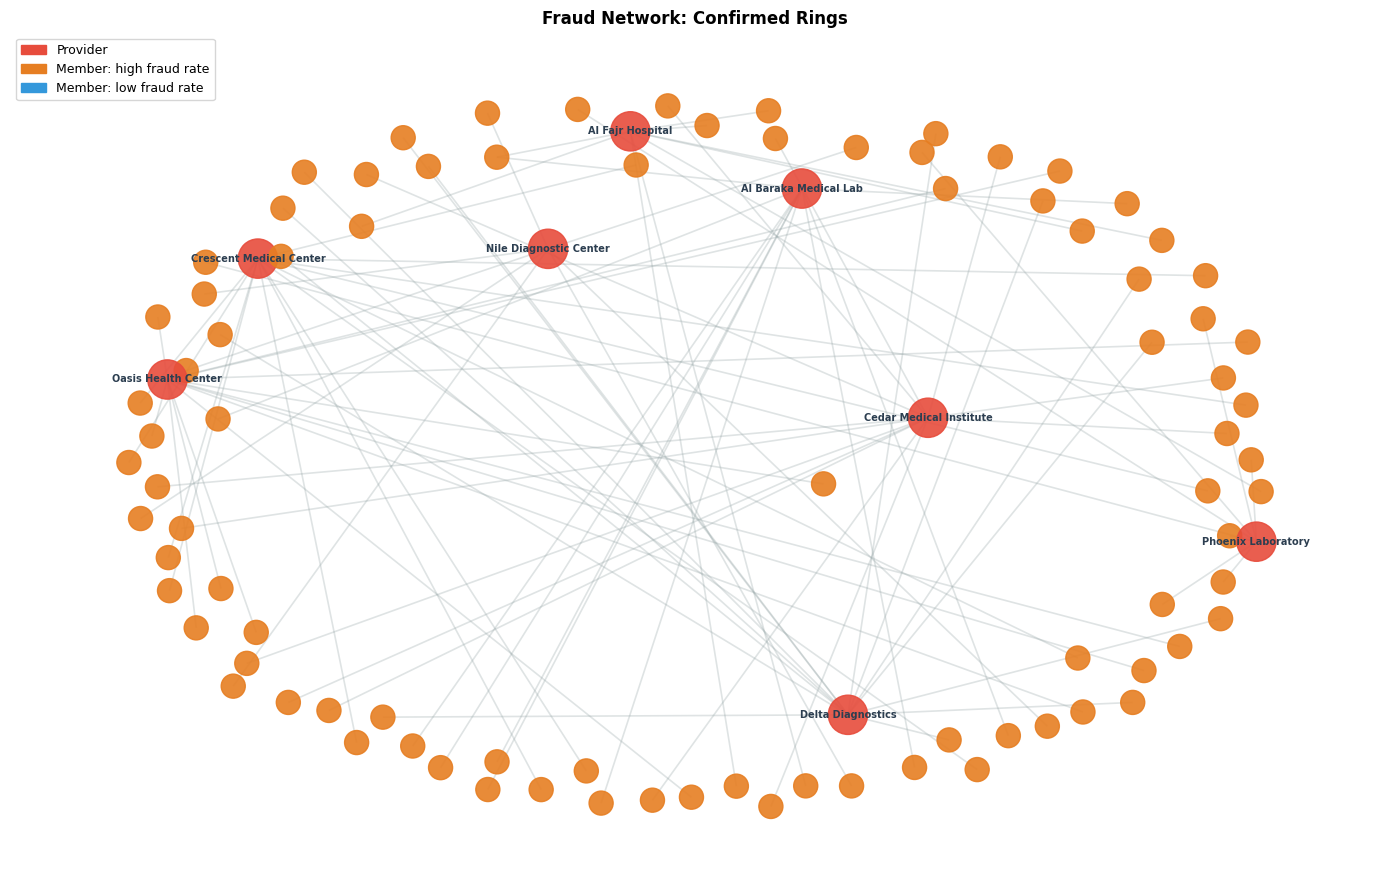

visualized: 95 nodes | saved: fraud_network.png


In [19]:
# Visualize fraud rings
if len(ring_providers) > 0:
    ring_members = df[df['in_fraud_ring']==1]['Contact Code'].unique().tolist()
    ring_nodes = set(ring_members + ring_providers)
    G_sub = G_mp.subgraph(ring_nodes)
else:
    small_clusters = cluster_stats[
        (cluster_stats['cluster_member_count'] >= 3) &
        (cluster_stats['cluster_member_count'] <= 10)
    ].sort_values('cluster_fraud_rate', ascending=False).head(5)
    top_nodes = set(
        df[df['network_cluster_id'].isin(small_clusters['network_cluster_id'].tolist())]['Contact Code'].tolist() +
        df[df['network_cluster_id'].isin(small_clusters['network_cluster_id'].tolist())]['Provider'].tolist()
    )
    G_sub = G_mp.subgraph(top_nodes)

provider_set = set(df['Provider'].unique())
node_colors, node_sizes = [], []
for node in G_sub.nodes():
    if node in provider_set:
        node_colors.append('#e74c3c')
        node_sizes.append(800)
    else:
        member_fraud = df[df['Contact Code']==node]['fraud_label'].mean()
        node_colors.append('#e67e22' if member_fraud >= 0.5 else '#3498db')
        node_sizes.append(300)

plt.figure(figsize=(14,9))
pos = nx.spring_layout(G_sub, seed=42, k=2)
nx.draw_networkx_edges(G_sub, pos, alpha=0.3, edge_color='#95a5a6', width=1.2)
nx.draw_networkx_nodes(G_sub, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_sub, pos,
    labels={n: n for n in G_sub.nodes() if n in provider_set},
    font_size=7, font_weight='bold', font_color='#2c3e50')
legend_elements = [
    mpatches.Patch(color='#e74c3c', label='Provider'),
    mpatches.Patch(color='#e67e22', label='Member: high fraud rate'),
    mpatches.Patch(color='#3498db', label='Member: low fraud rate'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=9)
plt.title('Fraud Network: Confirmed Rings', fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('fraud_network.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"visualized: {G_sub.number_of_nodes()} nodes | saved: fraud_network.png")

In [20]:
print("Calculating betweenness centrality (may take a few minutes)...")
betweenness = nx.betweenness_centrality(G_mp, normalized=True, endpoints=False)

df['member_betweenness']   = df['Contact Code'].map(betweenness).fillna(0).round(6)
df['provider_betweenness'] = df['Provider'].map(betweenness).fillna(0).round(6)

provider_bw = pd.DataFrame({
    'Provider': list(df['Provider'].unique()),
    'betweenness_centrality': [betweenness.get(p,0) for p in df['Provider'].unique()]
}).sort_values('betweenness_centrality', ascending=False)

member_bw = pd.DataFrame({
    'Contact Code': list(df['Contact Code'].unique()),
    'betweenness_centrality': [betweenness.get(m,0) for m in df['Contact Code'].unique()]
}).sort_values('betweenness_centrality', ascending=False)

print("\nTop 10 providers by betweenness (bridge nodes):")
print(provider_bw.head(10).to_string(index=False))
print("\nTop 10 members by betweenness:")
print(member_bw.head(10).to_string(index=False))

df['network_risk_score'] = (
    (df['in_fraud_ring'] * 40) +
    (df['network_member_degree'].clip(0,10) / 10 * 25) +
    (df['prov_fraud_rate'] * 20) +
    (df['provider_betweenness'] / provider_bw['betweenness_centrality'].max() * 15)
).clip(0,100).fillna(0)

print("\nnetwork risk score updated")
print(df['network_risk_score'].describe())

Calculating betweenness centrality (may take a few minutes)...

Top 10 providers by betweenness (bridge nodes):
               Provider  betweenness_centrality
      Delta Diagnostics                0.085244
Crescent Medical Center                0.073180
Cedar Medical Institute                0.072154
    Oasis Health Center                0.067050
  Al Baraka Medical Lab                0.063284
     Phoenix Laboratory                0.061949
       Al Fajr Hospital                0.059079
  Valley Medical Center                0.053403
   Nova Health Hospital                0.052945
 Nile Diagnostic Center                0.052928

Top 10 members by betweenness:
Contact Code  betweenness_centrality
  MXG13929R5                0.004218
 FVE23701R44                0.003446
 WQD26248R73                0.003171
 ZDF69956R15                0.003002
 GVU64357R87                0.002975
 WVL25260R25                0.002774
 KOX60738R96                0.002739
 QTW41276R22                0.00

## How I Weighted the Composite Score

Provider behavior gets the highest weight (35%) because one fraudulent provider affects hundreds of claims. A fraudulent member affects maybe a dozen. The damage scales differently.

I weighted member history at 25%, high enough to matter, low enough that a single suspicious claim doesn't tank an otherwise clean member's score.

Network centrality gets 10%, it's a strong signal but it's a derived metric, not a direct observation. I didn't want to over-rely on it.

The risk tiers (Low / Medium / High / Critical) are thresholds I set by looking at the score distribution and asking: at what score does this become urgent enough to investigate today vs this week vs this quarter. Critical means now.

## 12. Composite Fraud Score

Combines all five risk dimensions into one score per claim. Formula: **0.25 × Member + 0.35 × Provider + 0.15 × Diagnosis + 0.15 × Claim Pattern + 0.10 × Network**

Higher score = investigate sooner.

In [21]:
df['diag_count'] = df['ICDS'].fillna('').str.count(',') + 1

df['claim_pattern_risk'] = (
    df['is_night_claim'] * 20 +
    df['exact_duplicate'] * 25 +
    df['near_duplicate'] * 15 +
    df['repeated_30day_visit'] * 15 +
    df['incident_month_end'] * 10 +
    df['is_phantom'] * 15
).clip(0, 100)

df['diagnosis_risk'] = (
    df['diag_cost_outlier'] * 40 +
    df['is_vague_diagnosis'] * 30 +
    (df['diag_count'] >= 5).astype(int) * 30
).clip(0, 100)

for col in ['member_risk_score','provider_risk_score','diagnosis_risk',
            'claim_pattern_risk','network_risk_score','ml_score']:
    df[col] = df[col].fillna(0).clip(0, 100)

df['composite_fraud_score'] = (
    0.25 * df['member_risk_score'] +
    0.35 * df['provider_risk_score'] +
    0.15 * df['diagnosis_risk'] +
    0.15 * df['claim_pattern_risk'] +
    0.10 * df['network_risk_score']
).clip(0, 100).round(1)

df['final_risk_tier'] = pd.cut(
    df['composite_fraud_score'],
    bins=[0, 15, 35, 50, 100],
    labels=['Low','Medium','High','Critical'],
    include_lowest=True)

print(df['composite_fraud_score'].describe())
print("\nrisk tier distribution:")
print(df['final_risk_tier'].value_counts())
print("\ntop 10 highest-scoring claims:")
print(df[['Claim Case','Provider','composite_fraud_score','final_risk_tier',
          'member_risk_score','provider_risk_score','diagnosis_risk',
          'claim_pattern_risk','network_risk_score']
].sort_values('composite_fraud_score', ascending=False).head(10))

count    5000.000000
mean       29.887360
std         6.231014
min        13.600000
25%        25.300000
50%        29.800000
75%        34.200000
max        51.600000
Name: composite_fraud_score, dtype: float64

risk tier distribution:
final_risk_tier
Medium      3935
High        1052
Low            9
Critical       4
Name: count, dtype: int64

top 10 highest-scoring claims:
               Claim Case                 Provider  composite_fraud_score  \
5     CASE-XXX-26-5548220  Cedar Medical Institute                   51.6   
966   CASE-XXX-23-7474950  Cedar Medical Institute                   50.5   
1975  CASE-XXX-24-7490068  Cedar Medical Institute                   50.1   
3243  CASE-XXX-23-2568678  Cedar Medical Institute                   50.1   
4711  CASE-XXX-26-9206403  Cedar Medical Institute                   49.0   
3621  CASE-XXX-25-4905100  Cedar Medical Institute                   49.0   
159   CASE-XXX-23-7417252  Cedar Medical Institute                   49.0   
361  

## 13. Investigation Queue & Export

In [22]:
df['estimated_savings'] = np.where(
    df['overbill_amount'] > 0,
    df['overbill_amount'],
    np.where(df['final_risk_tier'].isin(['High','Critical']),
             df['Total Invoiced'] * 0.15, 0)
).round(2)

queue = df[df['final_risk_tier'].isin(['High','Critical'])].copy()
queue = queue.sort_values(
    ['composite_fraud_score','estimated_savings'], ascending=False
).reset_index(drop=True)
queue.index += 1
queue.index.name = 'Priority'

print(f"investigation queue: {len(queue)} claims")
print(f"estimated savings:   ${queue['estimated_savings'].sum():,.0f}")
print(queue[['Claim Case','Provider','composite_fraud_score',
             'final_risk_tier','estimated_savings','Claim Status']].head(15))

investigation queue: 1056 claims
estimated savings:   $213,566
                   Claim Case                 Provider  composite_fraud_score  \
Priority                                                                        
1         CASE-XXX-26-5548220  Cedar Medical Institute                   51.6   
2         CASE-XXX-23-7474950  Cedar Medical Institute                   50.5   
3         CASE-XXX-24-7490068  Cedar Medical Institute                   50.1   
4         CASE-XXX-23-2568678  Cedar Medical Institute                   50.1   
5         CASE-XXX-23-7417252  Cedar Medical Institute                   49.0   
6         CASE-XXX-25-4905100  Cedar Medical Institute                   49.0   
7         CASE-XXX-26-9206403  Cedar Medical Institute                   49.0   
8         CASE-XXX-23-7724865  Cedar Medical Institute                   48.7   
9         CASE-XXX-26-4644760  Cedar Medical Institute                   48.6   
10        CASE-XXX-23-9966154  Cedar Medical I

In [23]:
export_cols = [
    'Claim Case','Claim Code','Contact Code','Provider','Agency',
    'Claim Status','Claim Type Code','Business Line','Beneficiary Type','Gender',
    'Incident Date','Created At','incident_day_name','incident_month','incident_year',
    'incident_month_end','incident_hour','month_year',
    'Estimate','Total Invoiced','Total to Pay','Total Physician','Total Provider',
    'overbill_amount','overbill_pct','estimated_savings',
    'member_age','member_risk_score','member_total_claims',
    'member_distinct_providers','member_er_visits','member_avg_claim',
    'member_overbill_count','member_phantom_count','member_unbundle_count',
    'provider_specialty','provider_risk_score','prov_avg_claim','peer_avg_claim',
    'cost_vs_peer_pct','prov_audit_rate','prov_fraud_rate',
    'prov_vague_diag_rate','prov_duplicate_rate','diag_vs_peer_pct','prov_phantom_rate',
    'primary_diag_code','diag_count','diag_avg_cost',
    'cost_vs_diag_avg','diag_cost_outlier','is_vague_diagnosis',
    'is_night_claim','is_gracia','is_phantom','same_day_claim_count',
    'exact_duplicate','near_duplicate',
    'repeated_30day_visit','days_since_last_visit',
    'is_new_contract_claim','claim_pattern_risk','provider_friday_flag',
    'network_member_degree','network_provider_degree','network_agency_degree',
    'network_cluster_id','network_cluster_size','in_fraud_ring','suspicious_cluster',
    'network_risk_score','cluster_avg_score','cluster_fraud_rate',
    'cluster_member_count','cluster_provider_count','cluster_total_invoiced',
    'member_betweenness','provider_betweenness',
    'member_risk_score','provider_risk_score','diagnosis_risk',
    'claim_pattern_risk','network_risk_score','ml_score',
    'composite_fraud_score','final_risk_tier',
    'fraud_label','fraud_probability','fraud_score','estimated_savings'
]
export_cols = list(dict.fromkeys(export_cols))
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv('claims_fraud_scored_final.csv', index=False)
queue[[c for c in export_cols if c in queue.columns]].to_csv('investigation_queue_final.csv')

print(f"claims_fraud_scored_final.csv   — {len(df)} rows, {len(export_cols)} columns")
print(f"investigation_queue_final.csv   — {len(queue)} rows")
print(f"estimated savings               — ${queue['estimated_savings'].sum():,.0f}")

claims_fraud_scored_final.csv   — 5000 rows, 85 columns
investigation_queue_final.csv   — 1056 rows
estimated savings               — $213,566


## 14. Active Members Analysis (Production Data)

In [24]:
# NOTE: Synthetic production data used for demonstration purposes
prod = pd.read_csv('synthetic_production_data.csv')
prod['Starting_Date'] = pd.to_datetime(prod['Starting_Date'], errors='coerce')
prod['Ending_Date']   = pd.to_datetime(prod['Ending_Date'],   errors='coerce')

months = pd.date_range(start=prod['Starting_Date'].min(),
                       end=prod['Ending_Date'].max(), freq='MS')

results = []
for month in months:
    month_end = month + pd.offsets.MonthEnd(0)
    active = prod[
        (prod['Starting_Date'] <= month_end) &
        (prod['Ending_Date']   >= month)
    ]
    if len(active) == 0:
        continue
    results.append({'month': month.strftime('%Y-%m'),
                    'business_line': 'ALL',
                    'active_members': len(active),
                    'active_contracts': active['Contract Code'].nunique()})
    for bl, grp in active.groupby('Business_line'):
        results.append({'month': month.strftime('%Y-%m'),
                        'business_line': bl,
                        'active_members': len(grp),
                        'active_contracts': grp['Contract Code'].nunique()})

active_monthly = pd.DataFrame(results)
active_monthly.to_csv('active_members_monthly_detailed.csv', index=False)

print("peak active members by business line:")
print(active_monthly[active_monthly['business_line']!='ALL'].groupby(
    'business_line')['active_members'].max().sort_values(ascending=False))
print("\nactive_members_monthly_detailed.csv exported")

peak active members by business line:
business_line
Dental                     156
Medical                    156
Medical Group Colective    148
Personal Accident          140
Life Medical               133
Name: active_members, dtype: int64

active_members_monthly_detailed.csv exported


In [25]:
print("Python total estimated savings: ${:,.0f}".format(df['estimated_savings'].sum()))
print("Queue total estimated savings: ${:,.0f}".format(queue['estimated_savings'].sum()))

print("\nEstimated savings distribution:")
print(df['estimated_savings'].describe())

print("\nClaims with estimated_savings > 0:", (df['estimated_savings'] > 0).sum())
print("Max estimated savings single claim:", df['estimated_savings'].max())

print("\nTop 10 highest estimated savings claims:")
print(df[['Claim Case','Provider','Total Invoiced','overbill_amount',
          'final_risk_tier','estimated_savings']
].sort_values('estimated_savings', ascending=False).head(10))


Python total estimated savings: $361,474
Queue total estimated savings: $213,566

Estimated savings distribution:
count    5000.000000
mean       72.294726
std       179.536059
min         0.000000
25%         0.000000
50%         0.000000
75%        37.540000
max      2976.690000
Name: estimated_savings, dtype: float64

Claims with estimated_savings > 0: 1726
Max estimated savings single claim: 2976.69

Top 10 highest estimated savings claims:
               Claim Case                Provider  Total Invoiced  \
675   CASE-XXX-23-2734858   Valley Medical Center         5169.71   
1855  CASE-XXX-23-9715749   Valley Medical Center         3735.51   
4174  CASE-XXX-24-2232884   Valley Medical Center         4479.95   
3443  CASE-XXX-24-1956370    Sunrise Laboratories         2975.56   
468   CASE-XXX-26-7118624  Nile Diagnostic Center         2733.59   
4454  CASE-XXX-25-3762518        Al Fajr Hospital         2866.34   
4607  CASE-XXX-25-9483809        Gulf Care Clinic         2352.05   